In [7]:
from langgraph.graph import StateGraph, START, END
import os
from typing import List, TypedDict, Literal, Annotated
from langchain_core.messages import HumanMessage, SystemMessage, BaseMessage 
from langgraph.graph.message import add_messages
from langchain.chat_models import init_chat_model
import operator
from langgraph.checkpoint.memory import MemorySaver

In [8]:
model  = init_chat_model("google_genai:gemini-3-flash-preview")

In [9]:
class chatState(TypedDict):
    
    messages : Annotated[list[BaseMessage], add_messages]
    

In [10]:
def chat_node(state:chatState):
    ###take the messages from the state and invoke the model
    messages = state['messages']
    
    ### call the model and get the response
    response = model.invoke(messages)
    
    return {"messages": [response]}

In [11]:
checkpointer = MemorySaver()
graph = StateGraph(chatState)
graph.add_node("chat_node",chat_node)

graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)


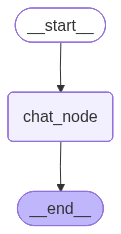

In [12]:
workflow = graph.compile(checkpointer=checkpointer)
workflow

In [13]:
thread1 =1
while True:
    user_input = input("User: ")
    if user_input.lower() in ["exit", "quit"]:
        print("Exiting the chatbot. Goodbye!")
        break
    
    config = {"configurable": {"thread_id": thread1}}
    
    result = workflow.invoke({"messages": [HumanMessage(content=user_input)]}, config=config)
    print("Chatbot:", result["messages"][-1].content)

Chatbot: [{'type': 'text', 'text': "Hi Avanish! It's nice to meet you. How can I help you today?", 'extras': {'signature': 'EvYCCvMCAQw51semkecHIFTIKpZV1cQTuq/nlDVga3e2BVJM2WiN+1/Ng3Hj1ampCHrq8Pn+FeDcmOU5SJG5wBRlj2Fuqh7PZVpLUmhL5CnGzwlaWvEKO0xjzeKIyTPQDPfP9XcChf4DXQgfEJXLNa9l7QPWi9TBvdbQ3/8vFF67Z861L+vkxo4ZhbOmbcLj3bE16wP/JR2FTx/8G2UC2M6XEHk3lElCci+Vh5FboNnbc7/Oly60A3l6MnU7BnFUxd95gbTTihYtr175L7Ha5Zar4Kf/73nkRJc+mHKLy9cNzf2C3UvRnIMWSSKsirIfI4I5AwpeUhxNeTvuhIr0kCyTQpnkeFCCeMkTkpjyAYl20xdHO/p+CtomCAGLuFg4yMA92NsenNc26bjHXL80+8umnCbnVdIKBmehmmF+5YafH69kulnhShHYsdmynX9+2v1CqBWv9Be//EnyXqH80KgKug5/sPP0H6POggZYq78T1y2w93AEwIg='}}]
Chatbot: [{'type': 'text', 'text': 'Your name is **Avanish**! How can I help you today?', 'extras': {'signature': 'EsoBCscBAQw51sd4VdYSFZii02gcfpf6LcQeKj/IRmtBQMKjwcf29+jwHsjBShm4dO1G4Utr3Esj7OGpnhZj4U1FXFoU7q0B8SfdWJVYYa3lDlEhPKuwknL2tKQzP3ArX5adSdegBBuwhfTwAnSAcbXuvv2m5F8J4i3f4lFVtBNZbCUBhqT96j1d0fwCF0QcDzmKRA0ICRTk0ikCSPRaR7QeardAgR0ET4/FthPxNnkZpjiUOFt+eXhH9zdK

ChatGoogleGenerativeAIError: Error calling model 'gemini-3-flash-preview' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3-flash\nPlease retry in 23.8728333s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-Fre

In [15]:
workflow.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hi my name is avanish', additional_kwargs={}, response_metadata={}, id='a6557f0b-ac76-4cf8-ba02-3f011a609c82'), AIMessage(content=[{'type': 'text', 'text': "Hi Avanish! It's nice to meet you. How can I help you today?", 'extras': {'signature': 'EvYCCvMCAQw51semkecHIFTIKpZV1cQTuq/nlDVga3e2BVJM2WiN+1/Ng3Hj1ampCHrq8Pn+FeDcmOU5SJG5wBRlj2Fuqh7PZVpLUmhL5CnGzwlaWvEKO0xjzeKIyTPQDPfP9XcChf4DXQgfEJXLNa9l7QPWi9TBvdbQ3/8vFF67Z861L+vkxo4ZhbOmbcLj3bE16wP/JR2FTx/8G2UC2M6XEHk3lElCci+Vh5FboNnbc7/Oly60A3l6MnU7BnFUxd95gbTTihYtr175L7Ha5Zar4Kf/73nkRJc+mHKLy9cNzf2C3UvRnIMWSSKsirIfI4I5AwpeUhxNeTvuhIr0kCyTQpnkeFCCeMkTkpjyAYl20xdHO/p+CtomCAGLuFg4yMA92NsenNc26bjHXL80+8umnCbnVdIKBmehmmF+5YafH69kulnhShHYsdmynX9+2v1CqBWv9Be//EnyXqH80KgKug5/sPP0H6POggZYq78T1y2w93AEwIg='}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3-flash-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019dc7e0-88c7

In [ ]:
# initial_state={
#     "messages":[HumanMessage(content="my name is avanish")]
# }

In [ ]:
# result = workflow.invoke(initial_state)
# print(result["messages"])

In [ ]:
# print(result["messages"])